# Punto_2_Modelos

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf
from skopt import BayesSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from sklearn.model_selection import GridSearchCV
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import explained_variance_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import mglearn
import plotly.express as px
from typing import Tuple, List, Any
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.svm import SVR
import matplotlib as mpl
from sklearn.ensemble import RandomForestRegressor
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## Clases y funciones 
'Time series split' customizado

In [2]:
class Data():
  def __init__(self, file, t, target):
    t = t *25
    file = (file.sort_values(by='time index')).reset_index(drop=True)
    self.X_train = (file.drop(target, axis='columns')).iloc[:-t]
    self.y_train = file[target].iloc[:-t]
    self.X_test = (file.drop(target, axis='columns')).iloc[-t:]
    self.y_test = file[target].iloc[-t:]
def training(*, model, sujeto, ejercicio):
    best_score = 0
    best_model = None
    best_params = None
    meta_param_grid = {
        'KNN'             : {'n_neighbors': [i for i in range(1,20)]},
        'Ridge'           : {'alpha': [0.1, 1, 10, 100]},
        'Lasso'           : {'alpha': [0.1, 0.5, 1, 5, 10]},
        'RandomForest'    : {'n_estimators': [50, 100, 200]},
        'Xg'              : { 'max_depth': [3, 4, 5, 6, 7], 'learning_rate': [0.1, 0.2, 0.3],  'n_estimators': [100, 200, 300]},
        'SVR'             : {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'epsilon': [0.1, 0.2, 0.5]}
    }
    if model == 'Linear':
        
        for t in [7, 14, 21, 28]:
            pipeline = Pipeline([('scaler', MinMaxScaler()), ('regressor', LinearRegression())])
            r2s_list = []
            data = return_of_df(sujeto, ejercicio, t)
            t_window = t * 25  # Calculate the window size
            for index in range(0, len(data.X_train), t_window):
                xtrain = data.X_train.iloc[index:index + t_window]
                ytrain = data.y_train.iloc[index:index + t_window]
                if len(xtrain) > 0 and len(ytrain) > 0:
                    try:
                        pipeline.fit(xtrain, ytrain)
                    except ValueError as e:
                        print(f"ValueError during pipeline fit: {e}")
                        continue

            try:
                r2 = r2_score(data.y_test, pipeline.predict(data.X_test))
                r2s_list.append(r2)
            except ValueError as e:
                print(f"ValueError during evaluation: {e}")
                continue

        r2 = np.mean(r2s_list)
        if r2 > best_score:
                best_score = r2
                best_model = pipeline
                best_params = {'X_test': data.X_test,
                               'y_test': data.y_test,}

    elif model == 'KNN':
        param_grid = meta_param_grid['KNN']
        for n_neighbors in param_grid['n_neighbors']:
            for t in [7, 14, 21, 28]:
                r2s_list = []
                if t > n_neighbors:
                    data = return_of_df(sujeto, ejercicio, t)  
                    t_window = t * 25  
                    model = Pipeline([('scaler', MinMaxScaler()), ('regressor', KNeighborsRegressor(n_neighbors=n_neighbors))])
                    for index in range(0, len(data.X_train), t_window):  
                        xtrain = data.X_train.iloc[index:index + t_window]
                        ytrain = data.y_train.iloc[index:index + t_window]
                        
                        if len(xtrain) > 0 and len(ytrain) > 0:
                            try:
                                model.fit(xtrain, ytrain)
                                r2 = r2_score(data.y_test, model.predict(data.X_test))
                                r2s_list.append(r2)
                            except ValueError as e:
                                print(f"ValueError during model fit or evaluation: {e}")
                                continue
                    r2 = np.mean(r2s_list)
                    if r2 > best_score:
                                    best_score = r2
                                    best_model = model.fit(data.X_train, data.y_train)
                                    best_params = {'X_test': data.X_test,
                                            'metricas' : calcular_metricas(data.y_test, model.predict(data.X_test)),       
                                            'y_test': data.y_test,
                                            'n_neighbors': n_neighbors}

    elif model == 'Ridge':
        
        param_grid = meta_param_grid['Ridge']
        for alpha in param_grid['alpha']:
            for t in [7, 14, 21, 28]:
                r2s_list = [] 
                model = Pipeline([('scaler', MinMaxScaler()), ('regressor', Ridge(alpha=alpha))])
                data = return_of_df(sujeto, ejercicio, t)
                t_window = t * 25  # Calculate the window size
                for index in range(0, len(data.X_train), t_window):  # Step through chunks
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]
                    
                    if len(xtrain) > 0 and len(ytrain) > 0:
                        try:
                            model.fit(xtrain, ytrain)
                            r2 = r2_score(data.y_test, model.predict(data.X_test))
                            r2s_list.append(r2)
                        except ValueError as e:
                            print(f"ValueError during model fit or evaluation: {e}")
                            continue
                r2 = np.mean(r2s_list)
                if r2 > best_score:
                                best_score = r2
                                best_model = model.fit(data.X_train, data.y_train)
                                best_params = {'X_test': data.X_test,
                                            'y_test': data.y_test,
                                            'alpha': alpha}

    elif model == 'Lasso':
        
        param_grid = meta_param_grid['Lasso']
        for alpha in param_grid['alpha']:
            for t in [7, 14, 21, 28]:
                r2s_list = []
                model = Lasso(alpha=alpha)
                data = return_of_df(sujeto, ejercicio, t)
                t_window = t * 25  # Calculate the window size
                for index in range(0, len(data.X_train), t_window):  # Step through chunks
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]

                    if len(xtrain) > 0 and len(ytrain) > 0:
                        
                        try:
                            model.fit(xtrain, ytrain)
                            r2 = r2_score(data.y_test, model.predict(data.X_test))
                            r2s_list.append(r2)
                        except ValueError as e:
                            print(f"ValueError during model fit or evaluation: {e}")
                            continue
                r2 = np.mean(r2s_list)
                if r2 > best_score:
                                best_score = r2
                                best_model = model.fit(data.X_train, data.y_train)
                                best_params = {'X_test': data.X_test,
                                            'y_test': data.y_test,
                                            'alpha': alpha}
    elif model == 'RandomForest':
        param_grid = meta_param_grid['RandomForest']
        for n_estimators in param_grid['n_estimators']:
            for t in [7, 14, 21, 28]:
                r2s_list = []
                model = RandomForestRegressor(n_estimators=n_estimators)
                data = return_of_df(sujeto, ejercicio, t)
                t_window = t * 25  # Calculate the window size
                for index in range(0, len(data.X_train), t_window):  # Step through chunks
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]

                    if len(xtrain) > 0 and len(ytrain) > 0:
                        try:
                            model.fit(xtrain, ytrain)
                            r2 = r2_score(data.y_test, model.predict(data.X_test))
                            r2s_list.append(r2)
                        except ValueError as e:
                            print(f"ValueError during model fit or evaluation: {e}")
                            continue
                r2 = np.mean(r2s_list)
                if r2 > best_score:
                                best_score = r2
                                best_model = model.fit(data.X_train, data.y_train)
                                best_params = {'X_test': data.X_test,
                                            'y_test': data.y_test,
                                            'n_estimators': n_estimators}
    elif model == 'Xg':
        param_grid = meta_param_grid['Xg']
        for max_depth in param_grid['max_depth']:
            for learning_rate in param_grid['learning_rate']:
                for n_estimators in param_grid['n_estimators']:
                    for t in [7, 14, 21, 28]:
                        model = XGBRegressor(max_depth=max_depth, learning_rate=learning_rate, n_estimators=n_estimators)
                        data = return_of_df(sujeto, ejercicio, t)
                        t_window = t * 25  
                        for index in range(0, len(data.X_train), t_window):  # Step through chunks
                            xtrain = data.X_train.iloc[index:index + t_window]
                            ytrain = data.y_train.iloc[index:index + t_window]

                            if len(xtrain) > 0 and len(ytrain) > 0:
                                try:
                                    model.fit(xtrain, ytrain)
                                    
                                except ValueError as e:
                                    print(f"ValueError during model fit or evaluation: {e}")
                                    continue
                    r2 = r2_score(data.y_test, model.predict(data.X_test))
                    if r2 > best_score:
                                        best_score = r2
                                        best_model = model
                                        best_params = {
                                            'X_test': data.X_test,
                                            'y_test': data.y_test,
                                            'max_depth': max_depth,
                                            'learning_rate': learning_rate,
                                            'n_estimators': n_estimators
                                        }
    elif model == 'SVR':
        from itertools import product
        param_grid = meta_param_grid['SVR']
        param_combinations = product(param_grid['kernel'], param_grid['C'], param_grid['gamma'], param_grid['epsilon'])
        
        for kernel, C, gamma, epsilon in param_combinations:
            for t in [7, 14, 21, 28]:
                model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon)
                
                data = return_of_df(sujeto, ejercicio, t)
                t_window = t * 25
                for index in range(0, len(data.X_train), t_window):
                    xtrain = data.X_train.iloc[index:index + t_window]
                    ytrain = data.y_train.iloc[index:index + t_window]
                    if len(xtrain) > 0 and len(ytrain) > 0:
                        try:
                            model.fit(xtrain, ytrain)
                        except ValueError as e:
                            print(f"ValueError during model fit: {e}")
                            continue
            mean_r2 = r2_score(data.y_test, model.predict(data.X_test))
            print(mean_r2)
            if mean_r2 > best_score:
                    
                    best_score = mean_r2
                    best_model = model
                    best_params = {
                        'X_test': data.X_test,
                        'y_test': data.y_test,
                        'kernel': kernel,
                        'C': C,
                        'gamma': gamma,
                        'epsilon': epsilon
                    }
    return best_score, best_model, best_params

def return_of_df( s, e, t ):
    target ='mag_y'
    for u in range(1, 6):
        data_frames = []
        temp_path = (f"C:/Users/loren/OneDrive/Escritorio/fisioterapia_dataset_regresion/s{s}/e{e}/u{u}/template_session.txt")
        if os.path.exists(temp_path):
                                try:
                                    temp_file = pd.read_csv(temp_path, delimiter=";")
                                    data_frames.append(temp_file)
                                except Exception as ex:
                                    pass
        else:
                                pass
    final_data = pd.concat(data_frames, ignore_index=True)
    data = Data(final_data, t, target)
    return data
def calcular_metricas(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    lb_test = acorr_ljungbox(y_true - y_pred, lags=[10], return_df=True)
    ljung_box_p_value = lb_test['lb_pvalue'].iloc[0]
    jb_test = jarque_bera(y_true - y_pred)
    jarque_bera_p_value = jb_test[1]

    return {
        'RMSE': [rmse],
        'MAPE': [mape],
        'R2': [r2],
        'Ljung-Box p-value': [ljung_box_p_value],
        'Jarque-Bera p-value': [jarque_bera_p_value]
    }

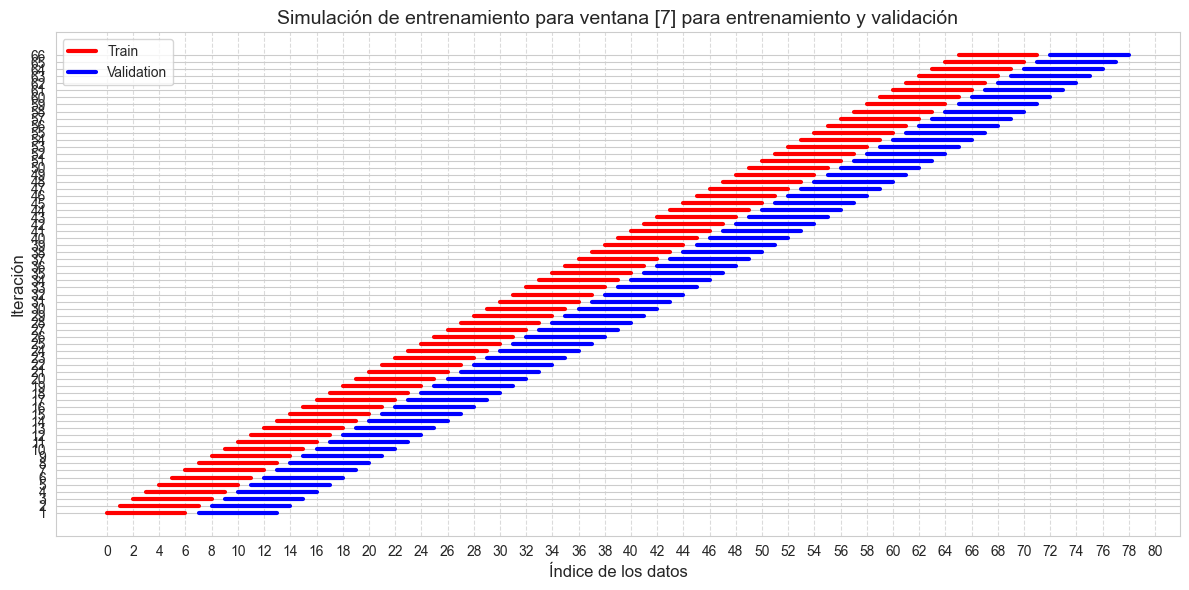

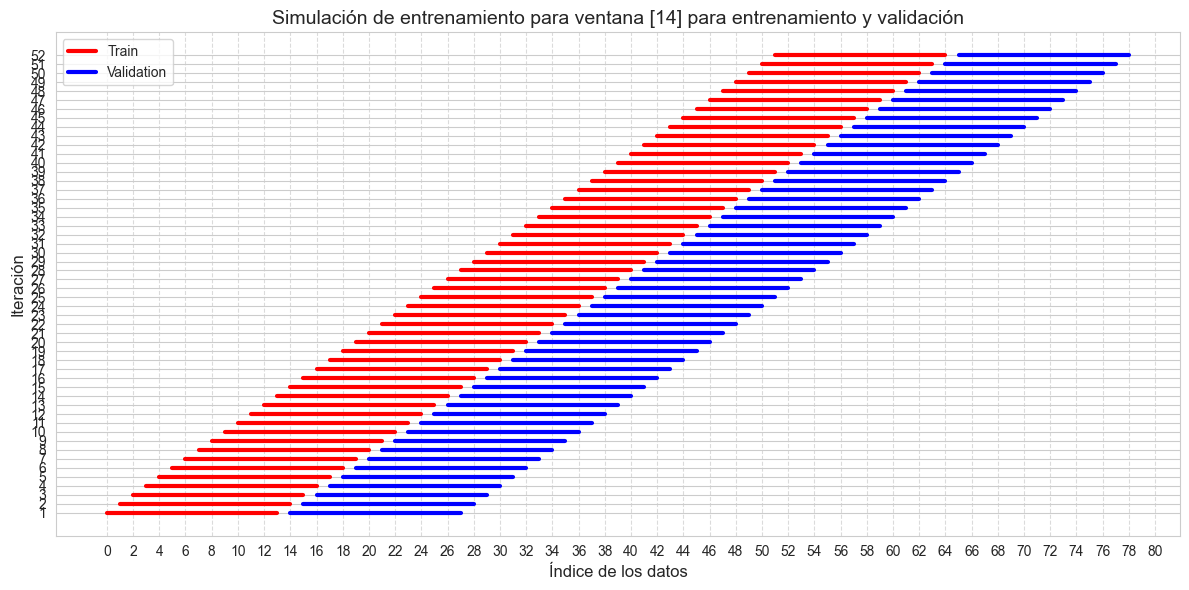

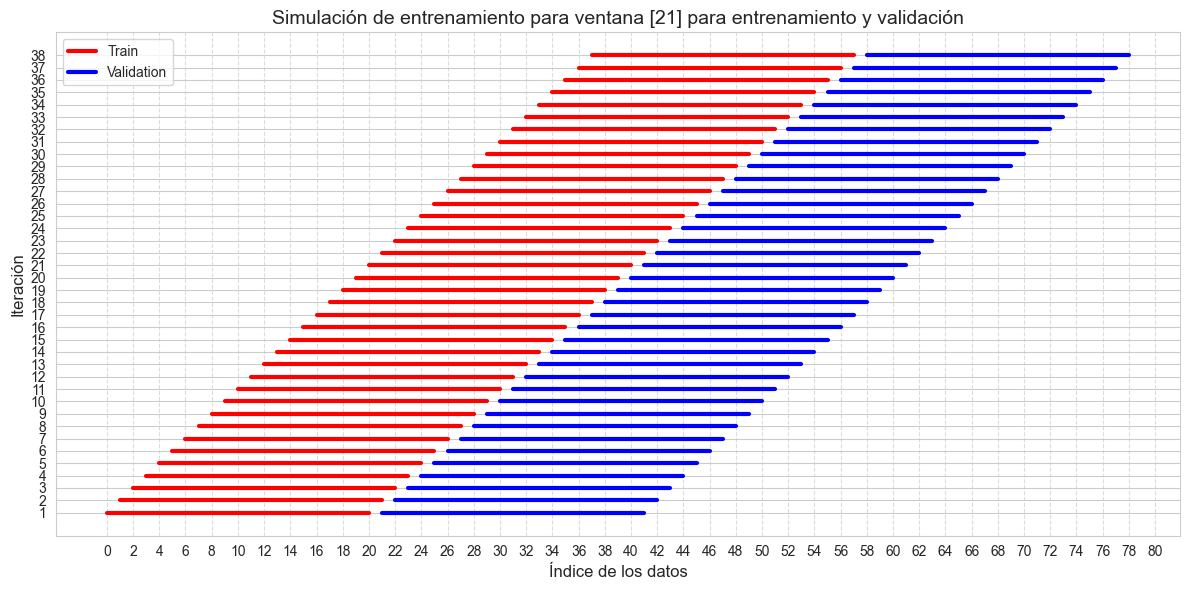

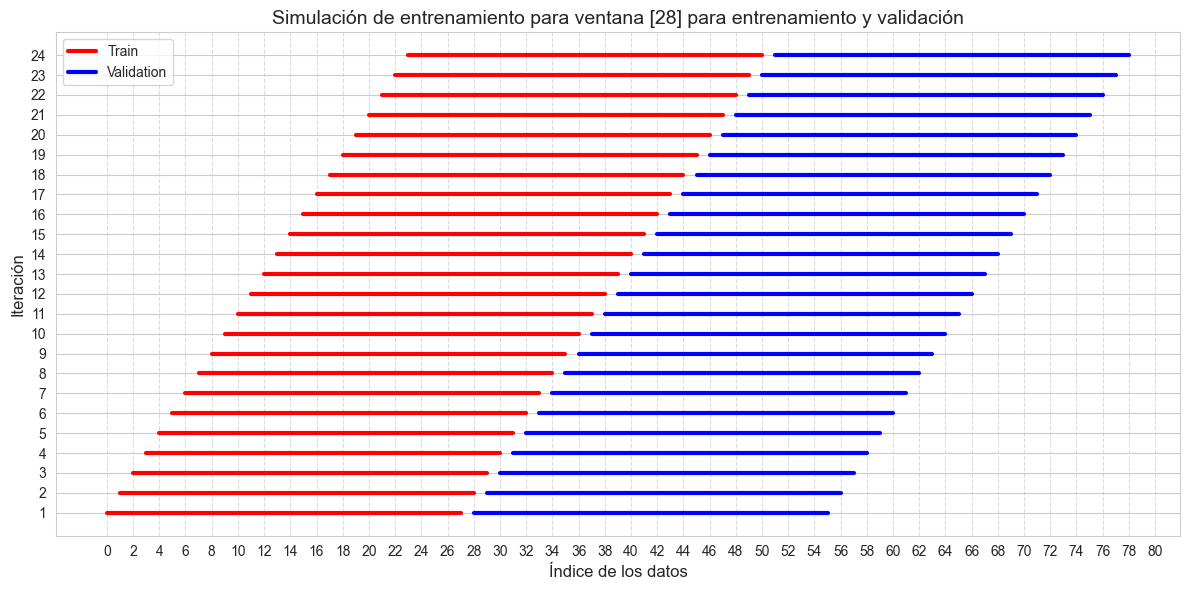

In [3]:
import matplotlib.pyplot as plt
for window  in [7,14,21,28]:
    total_points = 80
    train_window = window
    val_window = window
    stride = 1

    train_positions = []
    val_positions = []

    for start in range(0, total_points - train_window - val_window, stride):
        train_positions.append(range(start, start + train_window))
        val_positions.append(range(start + train_window, start + train_window + val_window))

    plt.figure(figsize=(12, 6))
    for i, (train, val) in enumerate(zip(train_positions, val_positions)):
        plt.plot(train, [i + 1] * len(train), 'r-', label='Train' if i == 0 else "", linewidth=3)
        plt.plot(val, [i + 1] * len(val), 'b-', label='Validation' if i == 0 else "", linewidth=3)

    plt.title(f"Simulación de entrenamiento para ventana [{window}] para entrenamiento y validación", fontsize=14)
    plt.xlabel("Índice de los datos", fontsize=12)
    plt.ylabel("Iteración", fontsize=12)
    plt.xticks(range(0, total_points + 1, 2))
    plt.yticks(range(1, len(train_positions) + 1))
    plt.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


## Estructura de organización de resultados
Los resultados fueron almacenados de manera que, por modelo, se evaluaban los 5 sujetos, luego los ejercicios y, finalmente, se agrupaban las unidades de un mismo ejercicio.

![](direc1.png)

![](direc2.png)

![](direc3.png)

Por lo que para almacenarlo de esta manera se uso el siguiente manejo de ciclos

In [4]:
OUTPUT_BASE_DIR = "C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_5"  # Actualiza esta ruta
'''
for model_type in ['KNN' ,'SVR', 'Xg', ]:#
            for s in range(1,6):
                for e in range(1, 8):
                        best_score, best_model, best_params = training(model=model_type, sujeto = s, ejercicio = e ) 
                        if best_model is not None:
                            file_path = os.path.join(
                                OUTPUT_BASE_DIR,
                                model_type,
                                f"s{s}",
                                f"e{e}",
                                "residuos-reales.csv"
                            )
                            file_path_0 = os.path.join(
                                OUTPUT_BASE_DIR,
                                model_type,
                                f"s{s}",
                                f"e{e}",
                                "metricas.txt"
                            )
                            dir_path = os.path.dirname(file_path)
                            
                            try:
                                os.makedirs(dir_path, exist_ok=True)
                                if os.path.isdir(file_path):
                                    print(f"Se esperaba un archivo pero se encontró un directorio: {file_path}")
                                
                                df = pd.DataFrame({
                                    'y_test': best_params['y_test'].to_list(),
                                    'pred': best_model.predict(best_params['X_test'])
                                })
                                df.to_csv(file_path, index=False)
                                

                                metricas = best_params['metricas']
                                print(best_score,metricas)
                                with open(file_path_0, 'w') as file:
                                    
                                    for key in metricas:
                                            file.write(f"{metricas[key][0]}\n")
                            
                            except OSError as ose:
                                print(f"Error de sistema operativo al crear directorios o escribir archivos: {ose}")
                            except Exception as ex: print(f"Error inesperado: {ex}") 
                            '''

'\nfor model_type in [\'KNN\' ,\'SVR\', \'Xg\', ]:#\n            for s in range(1,6):\n                for e in range(1, 8):\n                        best_score, best_model, best_params = training(model=model_type, sujeto = s, ejercicio = e ) \n                        if best_model is not None:\n                            file_path = os.path.join(\n                                OUTPUT_BASE_DIR,\n                                model_type,\n                                f"s{s}",\n                                f"e{e}",\n                                "residuos-reales.csv"\n                            )\n                            file_path_0 = os.path.join(\n                                OUTPUT_BASE_DIR,\n                                model_type,\n                                f"s{s}",\n                                f"e{e}",\n                                "metricas.txt"\n                            )\n                            dir_path = os.path.dirname(file_path)\n 

In [6]:
import pandas as pd
import plotly.graph_objects as go

sujeto = 3; ejercicio = 1;
t_window = 7
df = return_of_df(sujeto, ejercicio, t_window)
display((df.X_test).reset_index(drop=True))
display(df.y_train)

fig = go.Figure()
test  = df.y_test.to_list()
train = df.y_train.to_list() 
fig.add_trace(go.Box(
    y=train,
    name='Train',
    marker_color='blue',
    boxmean=True  # Muestra la media en el box plot
))

# Añadir el box plot para 'Test'
fig.add_trace(go.Box(
    y=test,
    name='Test',
    marker_color='orange',
    boxmean=True
))

# Personalizar el diseño
fig.update_layout(
    title='Distribución de Valores para Train y Test',
    xaxis_title='Conjunto de Datos',
    yaxis_title='Valores',
    template='plotly_white',
    boxmode='group'  # Agrupa los box plots
)
fig.show()

,time index,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,mag_x,mag_z
0,1192,-2.362091,-9.377503,-1.779811,-0.022518,-0.002062,-0.004521,-0.190239,-0.001387
1,1193,-2.359624,-9.367698,-1.833740,0.007495,-0.005938,0.011405,-0.191535,-0.001570
2,1194,-2.393704,-9.386943,-1.838812,0.035380,-0.019586,0.001683,-0.190787,-0.002053
3,1195,-2.349982,-9.338728,-1.770521,0.026583,-0.007157,-0.006235,-0.191345,-0.002876
4,1196,-2.459769,-9.314066,-1.679694,0.012238,-0.001746,-0.004502,-0.191621,-0.003262
...,...,...,...,...,...,...,...,...,...
170,1362,-2.501146,-9.357621,-1.652665,-0.002312,-0.001515,0.008713,-0.179508,-0.010412
171,1363,-2.496255,-9.364922,-1.657355,0.002196,0.005730,0.006085,-0.179625,-0.010180
172,1364,-2.508433,-9.372160,-1.650078,-0.003695,-0.007463,-0.009851,-0.180542,-0.010498
173,1365,-2.506059,-9.338182,-1.645743,-0.001697,0.006809,-0.021296,-0.180703,-0.011132


0       0.766255
1       0.766029
2       0.766459
3       0.766299
4       0.766739
          ...   
1186    0.764716
1187    0.765458
1188    0.763864
1189    0.765188
1190    0.764778
Name: mag_y, Length: 1191, dtype: float64

En esta ocasión, tenemos los gráficos boxplot para un ejemplo de train y test utilizados para la construcción de los modelos en el ciclo de iteraciones. Vemos que ambos gráficos tienen un rango diferente, con cero datos atípicos. Es importante apreciar la anchura de las cajas, donde se nota cómo los datos tienen una variabilidad parecida para ambos conjuntos. Finalmente, la mediana de estos se encuentra bastante cercana entre sí, siendo prácticamente iguales; por ejemplo, para el train la mediana es de `0.76506` y para el test `0.76557`.

## Resultados

In [7]:
dx = {}
names_metrics = {0:'RMSE', 1:'MAPE',2:'R2',3:'Ljung-Box p-value', 4:'Jarque-Bera p-value'}
models = [ "Lasso"]
for model in models:
    max_r2 = 0 
    for s in range(1, 6):
        for e in range(1, 7):
            if e != 4:
                path = f"C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/{model}/s{s}/e{e}/metricas.txt"
                try:
                    with open(path, 'r') as file:
                        lines = file.readlines()
                        
                        r2 = (float(lines[2].strip()))
                        if r2> max_r2 :
                            sub_dx = {}
                            for i in range(5):
                                sub_dx[names_metrics[i]] = float(lines[i].strip())
                            dx[model] = (sub_dx,  path[:-12]+'residuos-reales.csv')
                except FileNotFoundError:
                    print(f"El archivo no existe: {path}")


El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s1/e3/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s1/e5/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s1/e6/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s2/e1/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s2/e2/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s2/e3/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s2/e5/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s2/e6/metricas.txt
El archivo no existe: C:/Users/loren/OneDrive/Escritorio/practico-final/

In [9]:
final_results = {'Lasso': ({'RMSE': 0.008296051618554425,
   'MAPE': 0.744073211667643,
   'R2': 0.11217118055376418,
   'Ljung-Box p-value': 0.0,
   'Jarque-Bera p-value': 9.151441429244189e-151},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s1/e2/residuos-reales.csv'),
'Linear': ({'RMSE': 0.0016815181913567177,
   'MAPE': 0.3863987136766709,
   'R2': 0.9768742536831282,
   'Ljung-Box p-value': 3.380712056894513e-70,
   'Jarque-Bera p-value': 0.04818960395797039},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_4/Linear/s5/e6/residuos-reales.csv'),
 'RandomForest': ({'RMSE': 0.002281712420891798,
   'MAPE': 0.19332706928961577,
   'R2': 0.9471856378654467,
   'Ljung-Box p-value': 1.933292782628356e-201,
   'Jarque-Bera p-value': 0.0},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_4/RandomForest/s5/e5/residuos-reales.csv'),
 'Ridge': ({'RMSE': 0.0017211770061593334,
   'MAPE': 0.3988031261938676,
   'R2': 0.9757705426180725,
   'Ljung-Box p-value': 2.0099601772324456e-112,
   'Jarque-Bera p-value': 0.0584228455777267},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_4/Ridge/s5/e6/residuos-reales.csv'),  
  'KNN': ({'RMSE': 0.008990389871200833,
   'MAPE': 2.418389945584074,
   'R2': 0.11455368649993913,
   'Ljung-Box p-value': 0.0,
   'Jarque-Bera p-value': 1.941756312953026e-12},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_5/KNN/s5/e6/residuos-reales.csv'),
 'Xg': ({'RMSE': 0.002943228406120193,
   'MAPE': 0.25576609888739377,
   'R2': 0.949534714512149,
   'Ljung-Box p-value': 9.706542270109116e-288,
   'Jarque-Bera p-value': 0.0},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_5/Xg/s5/e5/residuos-reales.csv'),
 'SVR': ({'RMSE': 2.4222128447033215,
   'MAPE': 62.79985592502104,
   'R2': 0.8035093859476218,
   'Ljung-Box p-value': 6.396102813496151e-201,
   'Jarque-Bera p-value': 0.13513807962168223},
  'C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final/7/SVR/acc_x/s5/e6/residuos-reales.csv')
 }

### Análisis de Predicciones y Residuos

#### Modelo Lineal Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

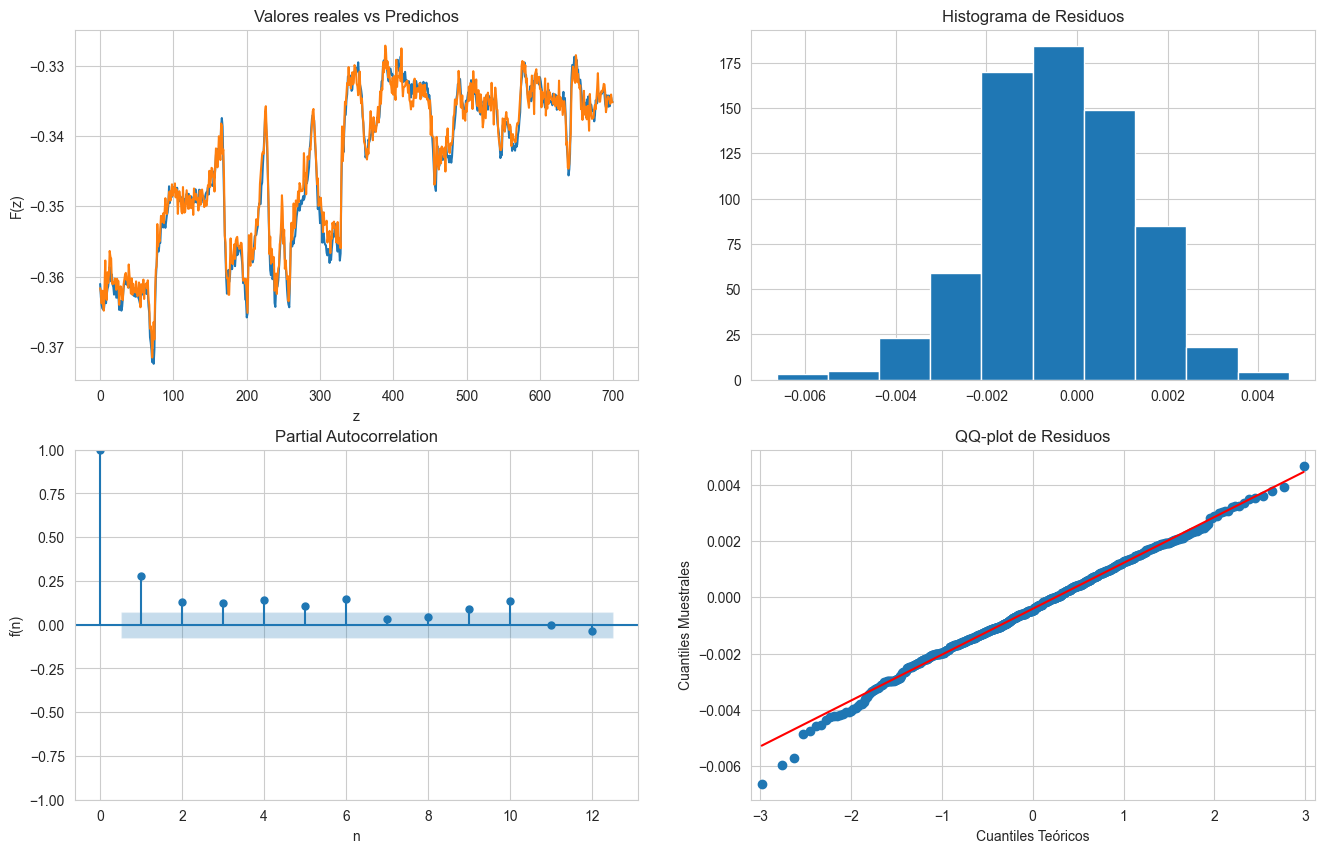

In [10]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_4/Linear/s5/e6/residuos-reales.csv')

y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados mostrados, se evalúa el desempeño de un modelo predictivo mediante el análisis de los residuos. La gráfica de valores reales versus predichos indica un ajuste razonable entre las observaciones y las estimaciones. El histograma de residuos sugiere una distribución cercana a la normalidad, aunque podría haber leves sesgos. La gráfica de autocorrelación parcial muestra que los residuos no presentan correlación significativa, lo que implica independencia. Por último, el QQ-plot confirma que los residuos se ajustan adecuadamente a una distribución normal, ya que los puntos se alinean con la diagonal. En conjunto, estos análisis indican que el modelo es adecuado y cumple con los supuestos estadísticos básicos.



#### Modelo Knn Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

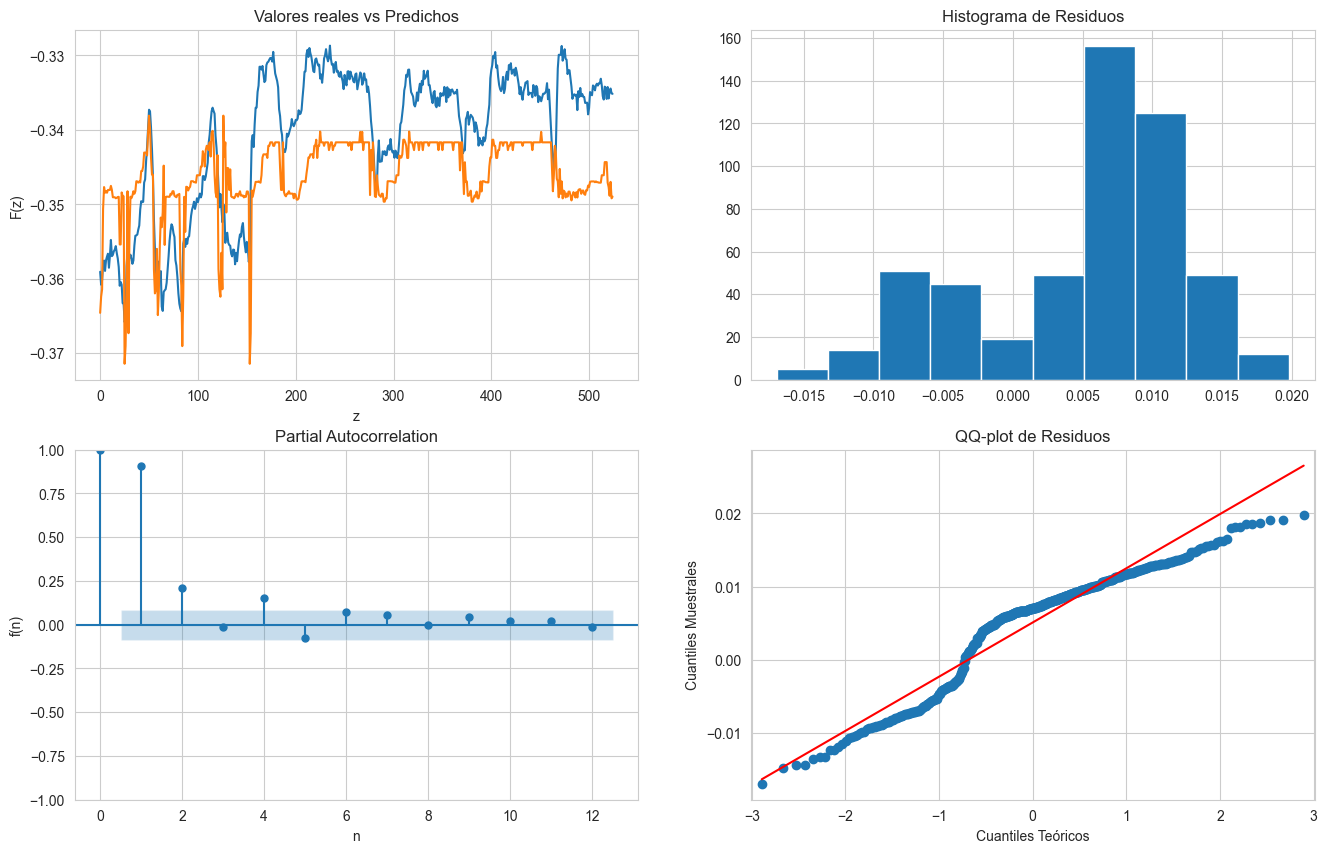

In [11]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_5/KNN/s5/e6/residuos-reales.csv')

y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados mostrados, se observa que la gráfica de valores reales versus predichos (arriba izquierda) refleja una discrepancia notable entre las predicciones y los valores observados, indicando un ajuste subóptimo del modelo. El histograma de residuos (arriba derecha) presenta una distribución asimétrica y desplazada, lo que sugiere que los errores no siguen una distribución normal. La gráfica de autocorrelación parcial (abajo izquierda) muestra algunas correlaciones significativas, indicando que los residuos no son completamente independientes, lo cual viola un supuesto clave del modelo. Por último, el QQ-plot (abajo derecha) evidencia que los residuos se desvían de la diagonal ideal, confirmando que no se ajustan a una distribución normal. Estos resultados sugieren que el modelo necesita ajustes o que no es el más adecuado para este conjunto de datos.


## Modelo Ridge Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

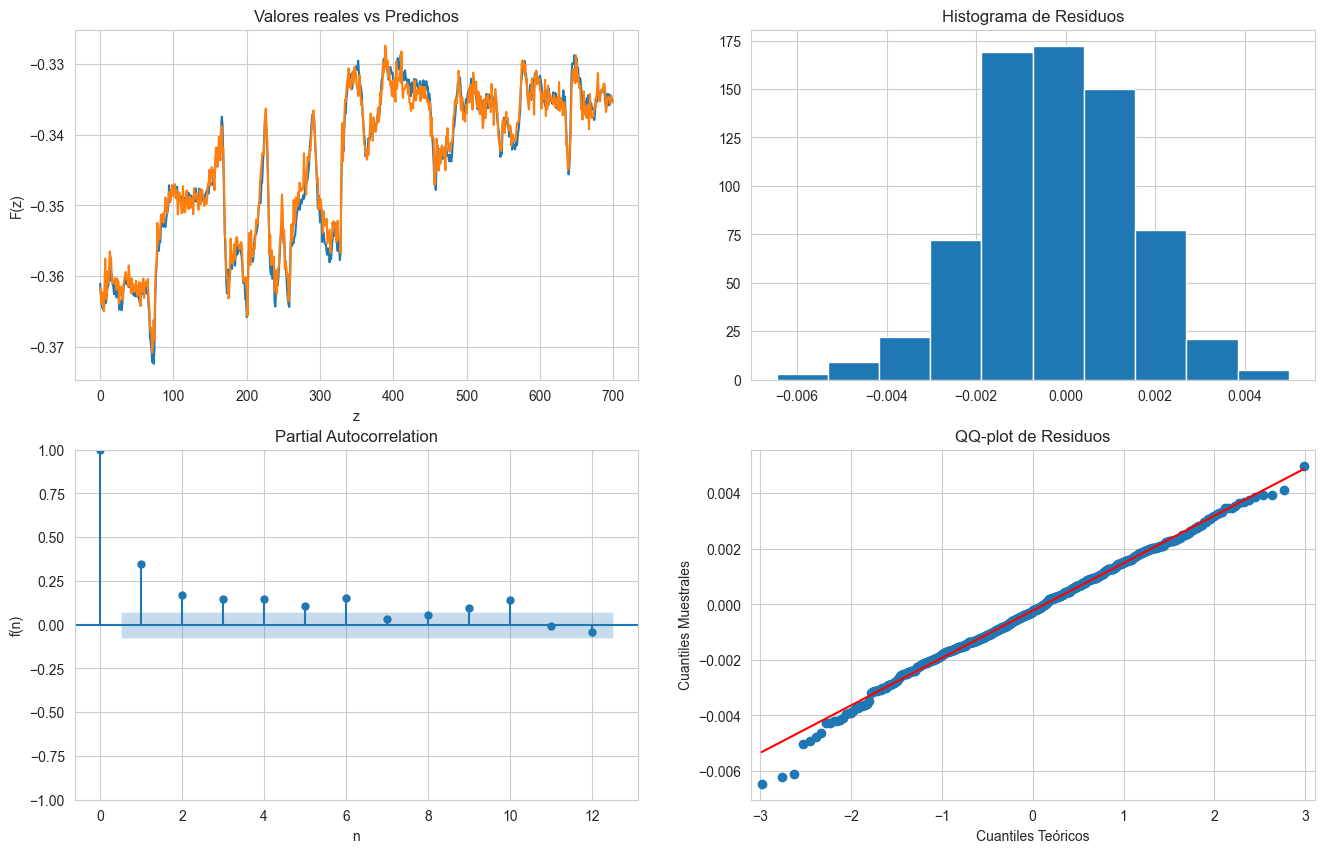

In [12]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_4/Ridge/s5/e6/residuos-reales.csv')

y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados presentados, el análisis muestra que los valores reales y predichos (gráfica superior izquierda) tienen un ajuste razonable, indicando un buen desempeño general del modelo. El histograma de residuos (gráfica superior derecha) exhibe una distribución simétrica cercana a la normalidad, lo cual es favorable para la validez del modelo. La gráfica de autocorrelación parcial (gráfica inferior izquierda) no presenta correlaciones significativas, lo que sugiere independencia entre los residuos. Por último, el QQ-plot (gráfica inferior derecha) evidencia que los residuos se ajustan correctamente a una distribución normal, dado que los puntos se alinean bien con la diagonal. En conjunto, estos resultados respaldan la adecuación del modelo al conjunto de datos.


#### Modelo Lasso Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

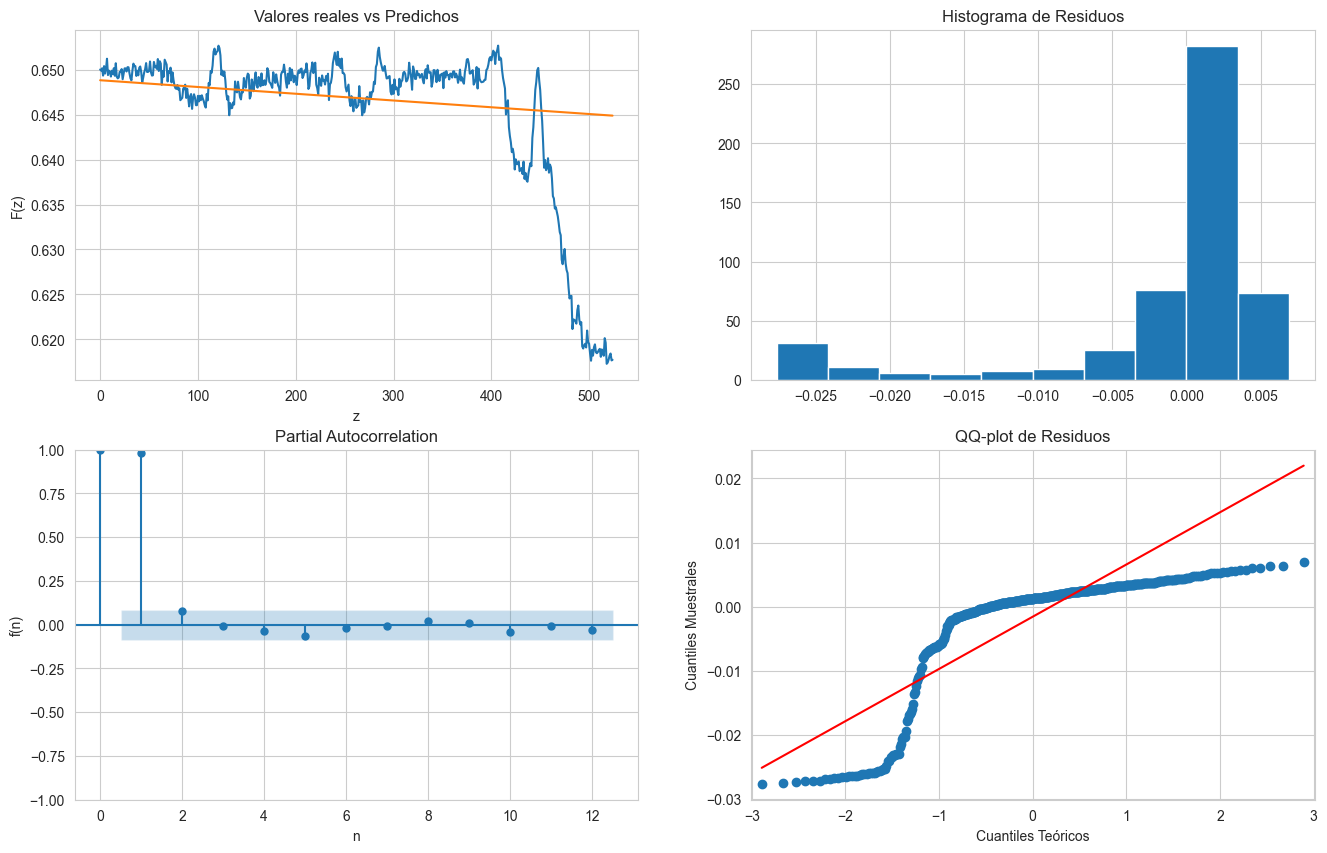

In [13]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_3/Lasso/s1/e2/residuos-reales.csv')

y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados mostrados, la gráfica de valores reales vs. predichos (arriba izquierda) evidencia un ajuste deficiente del modelo, con predicciones que no logran capturar adecuadamente el comportamiento de los datos reales, especialmente en las últimas observaciones. El histograma de residuos (arriba derecha) presenta una asimetría significativa, lo que indica que los errores no siguen una distribución normal. La gráfica de autocorrelación parcial (abajo izquierda) no muestra correlaciones significativas, sugiriendo independencia en los residuos. Sin embargo, el QQ-plot (abajo derecha) revela que los residuos se desvían considerablemente de la diagonal ideal, confirmando que no cumplen con el supuesto de normalidad. Estos resultados indican que el modelo no es adecuado para este conjunto de datos y requiere ajustes significativos o considerar otro enfoque.


#### Modelo Random Forest Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

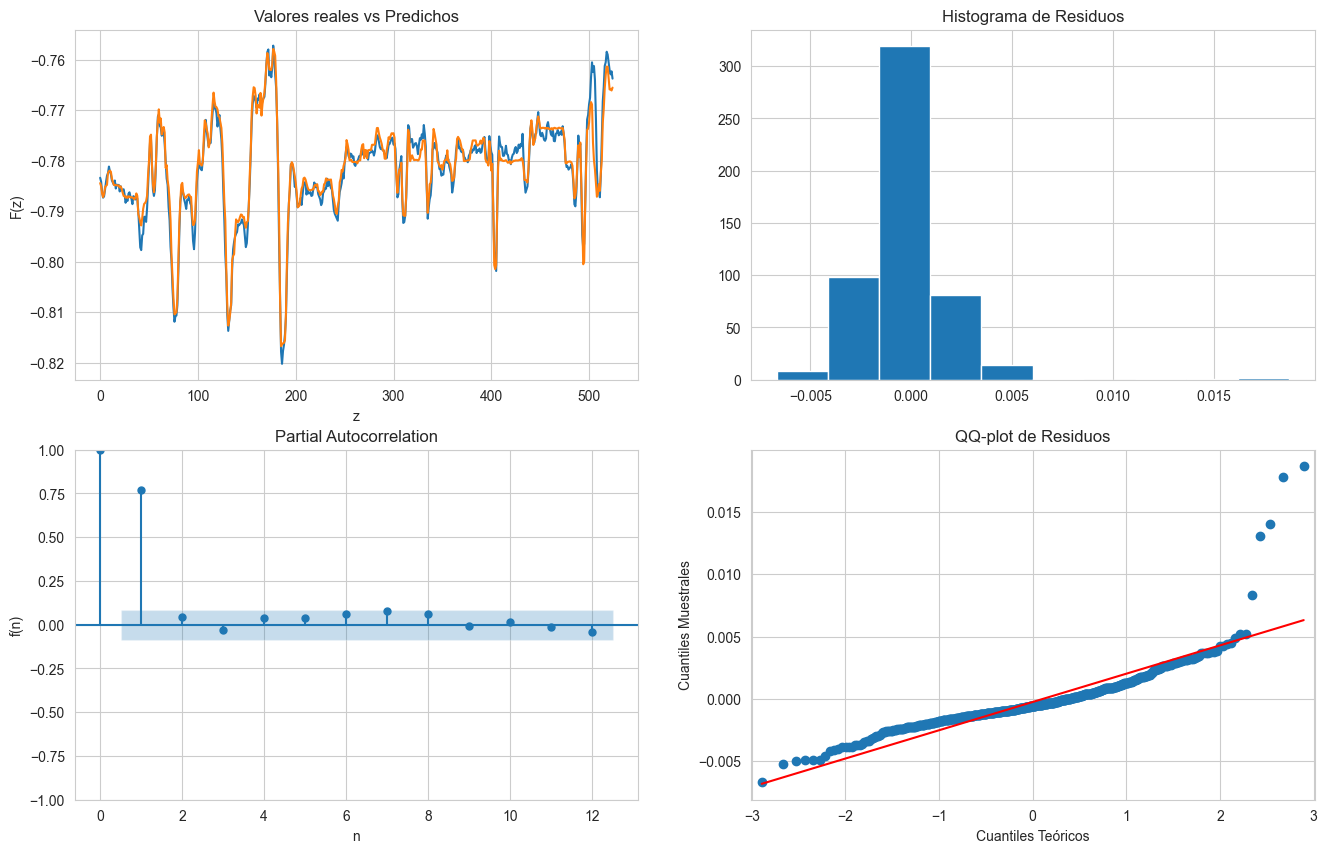

In [14]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_4/RandomForest/s5/e5/residuos-reales.csv')

y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados presentados, la gráfica de valores reales versus predichos (arriba izquierda) muestra un buen ajuste entre las predicciones y los valores reales, lo que indica que el modelo captura adecuadamente el comportamiento de los datos. El histograma de residuos (arriba derecha) revela una distribución simétrica centrada en cero, lo que sugiere que los errores están equilibrados y no presentan sesgos significativos. La gráfica de autocorrelación parcial (abajo izquierda) indica que no hay correlaciones significativas entre los residuos, lo cual es un indicador de independencia. Sin embargo, el QQ-plot (abajo derecha) evidencia algunas desviaciones en los extremos, lo que podría implicar ligeras violaciones al supuesto de normalidad. En general, el modelo muestra un desempeño sólido, aunque podrían investigarse las desviaciones en los extremos para mejorar el ajuste.


#### Modelo XGboost Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

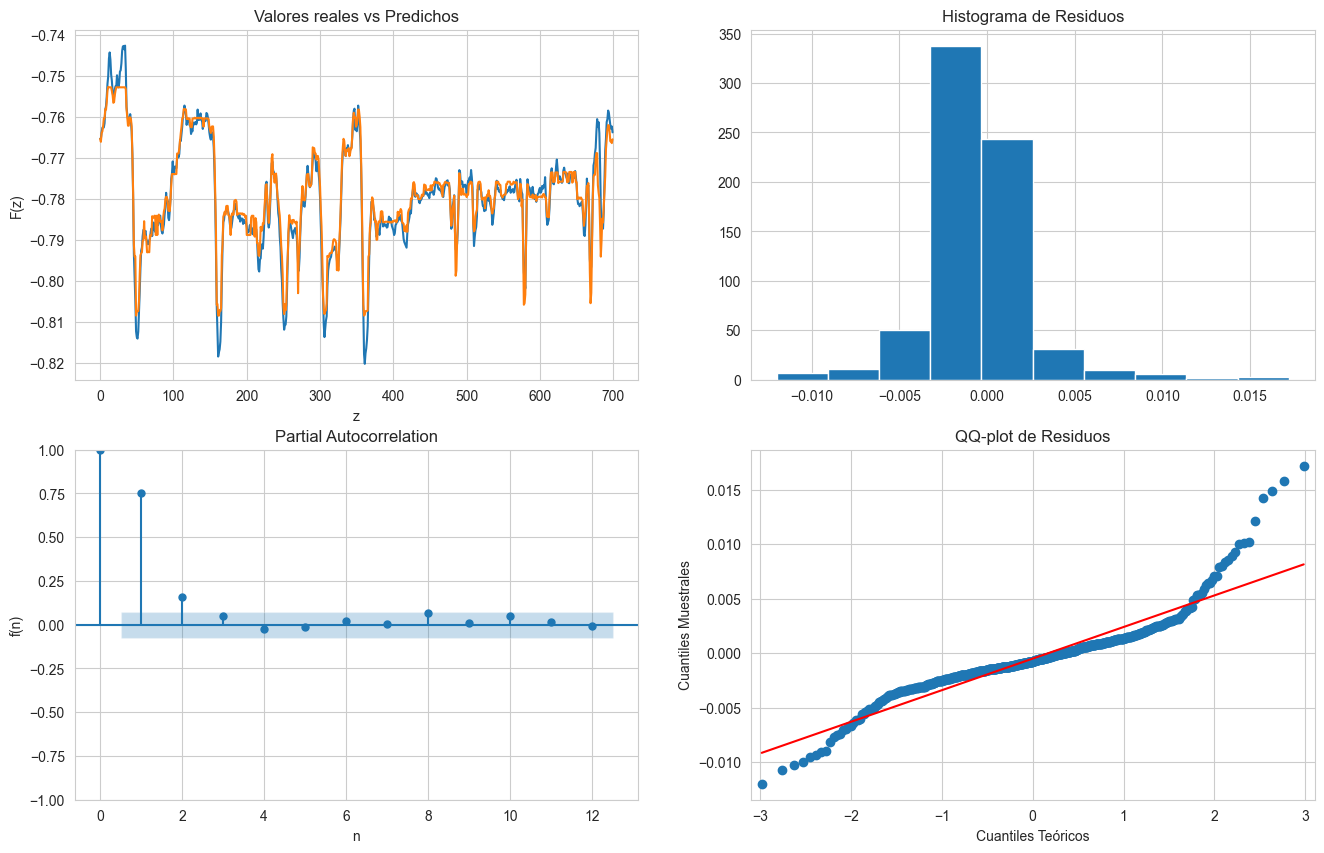

In [16]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final_5/Xg/s5/e5/residuos-reales.csv')


y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados presentados, la gráfica de valores reales versus predichos (arriba izquierda) muestra un ajuste consistente, indicando que el modelo predice con precisión en la mayoría de los casos, aunque hay ligeras desviaciones en algunos puntos. El histograma de residuos (arriba derecha) revela una distribución aproximadamente simétrica centrada en cero, lo que sugiere una buena neutralidad en los errores. La gráfica de autocorrelación parcial (abajo izquierda) no muestra correlaciones significativas, respaldando la independencia de los residuos. Sin embargo, el QQ-plot (abajo derecha) indica ciertas desviaciones en los extremos, lo que sugiere que los residuos no siguen completamente una distribución normal. En general, el modelo tiene un buen desempeño, aunque los extremos de la distribución de errores podrían mejorarse para optimizar los resultados.


#### Modelo SVR Regressor

Text(0, 0.5, 'Cuantiles Muestrales')

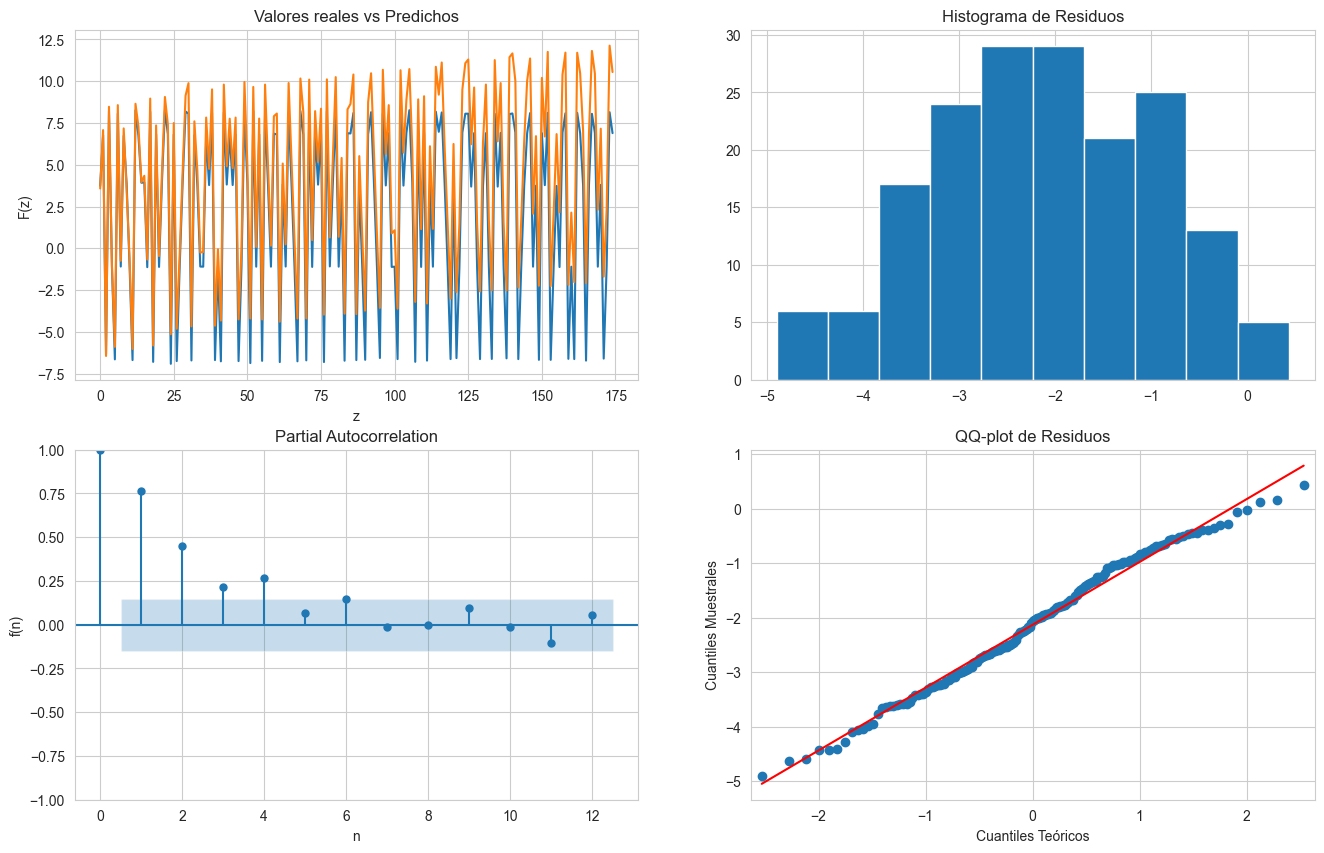

In [17]:
fig,ax=plt.subplots(2,2);fig.set_size_inches(16,10);

csv = pd.read_csv('C:/Users/loren/OneDrive/Escritorio/practico-final/Carpeta_ML_final/7/SVR/acc_x/s5/e6/residuos-reales.csv')


y2 = csv['y_test'].to_list()
y1 = csv['pred'].to_list()
residuos_lineales = [float(y_2)-float(y_1) for y_2, y_1 in zip(y2,y1)]
data = pd.DataFrame({
    'Predicciones': y1,
    'Valores Reales': y2,
    'residuos': residuos_lineales
})

ax[0][0].set_title('Valores reales vs Predichos')
ax[0][0].plot(data[ 'Valores Reales'],'-')
ax[0][0].plot(data['Predicciones'],'-')
ax[0][0].set_ylabel('F(z)')
ax[0][0].set_xlabel('z')

plot_pacf(residuos_lineales, lags=12, ax=ax[1][0])
ax[1][0].set_ylabel('f(n)')
ax[1][0].set_xlabel('n')

ax[0][1].set_title('Histograma de Residuos')
ax[0][1].hist(data['residuos'])

sm.qqplot(data['residuos'], line='s', ax=ax[1][1])
ax[1][1].set_title('QQ-plot de Residuos')
ax[1][1].set_xlabel('Cuantiles Teóricos')
ax[1][1].set_ylabel('Cuantiles Muestrales')

En los resultados presentados, la gráfica de valores reales versus predichos (arriba izquierda) muestra una considerable variabilidad y oscilaciones en las predicciones, lo que podría indicar que el modelo no captura adecuadamente la estructura del problema. El histograma de residuos (arriba derecha) sugiere una distribución que tiende a la simetría, aunque con una dispersión más pronunciada en los extremos. La gráfica de autocorrelación parcial (abajo izquierda) indica independencia en los residuos, ya que no se observan correlaciones significativas. El QQ-plot (abajo derecha) muestra alineación razonable de los puntos con la línea de referencia, aunque los extremos presentan desviaciones notables, lo que sugiere una ligera violación del supuesto de normalidad. En general, el modelo presenta resultados mixtos, con áreas de mejora evidentes en la estabilidad de las predicciones.


### Tabla final

In [27]:
dx = {'modelos':[], 'RMSE':[],'MAPE':[],'R2':[], 'L-jungbox':[], 'Jarque_bera':[]}
for i in final_results:
    all = [val[1] for val in (list(final_results[i][0].items()))]
    dx['modelos'].append(i)
    dx['RMSE'].append(all[0])
    dx['MAPE'].append(all[1])
    dx['R2'].append(all[2])
    dx['L-jungbox'].append(all[3])
    dx['Jarque_bera'].append(all[4])
display(pd.DataFrame(dx))

,modelos,RMSE,MAPE,R2,L-jungbox,Jarque_bera
0,Lasso,0.008296,0.744073,0.112171,0.000000e+00,9.151441e-151
1,Linear,0.001682,0.386399,0.976874,3.380712e-70,4.818960e-02
2,RandomForest,0.002282,0.193327,0.947186,1.933293e-201,0.000000e+00
3,Ridge,0.001721,0.398803,0.975771,2.009960e-112,5.842285e-02
4,KNN,0.008990,2.418390,0.114554,0.000000e+00,1.941756e-12
5,Xg,0.002943,0.255766,0.949535,9.706542e-288,0.000000e+00
6,SVR,2.422213,62.799856,0.803509,6.396103e-201,1.351381e-01


A partir de los resultados obtenidos en la tabla, el modelo **Linear Regression** muestra el mejor desempeño general, con un `RMSE` bajo (`0.001682`), un `MAPE` razonable (`0.386399`) y un coeficiente de determinación `R^2` elevado (`0.976874`), lo que indica un ajuste preciso y errores mínimos. El modelo **Ridge Regression** también presenta un desempeño competitivo, con métricas similares (`R^2 = 0.975771`) y un `RMSE` ligeramente mayor (`0.001721`). Por otro lado, el modelo **Random Forest** se posiciona como una alternativa viable con un `R^2 = 0.947186` y un `MAPE` menor que otros modelos, aunque su `RMSE` (`0.002282`) es más alto. En contraste, el modelo **SVR** muestra el peor desempeño, con un `RMSE` muy elevado (`2.422213`) y un `MAPE` extremadamente alto (`62.799856`), lo que lo hace inadecuado para este conjunto de datos. En general, los modelos **Linear** y **Ridge** destacan por su precisión y consistencia, siendo las mejores opciones para esta tarea.

